In [1]:
%pip install yfinance pandas numpy matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf, pandas as pd, numpy as np, matplotlib, sklearn
print('ok', len(yf.Ticker('AAPL').history(period='5d')), 'days pulled')

ok 5 days pulled


In [3]:
import sys, pathlib

G, R, D, B, OFF = "\033[32m", "\033[31m", "\033[2m", "\033[1m", "\033[0m"
ok = True

print(f"\n{B}Homework 1 self-check: your environment{OFF}\n")

v = sys.version_info
good = v >= (3, 9)
print(f"  {G + 'pass' + OFF if good else R + 'FAIL' + OFF}  Python {v.major}.{v.minor}.{v.micro}")
if not good:
    print(f"        {D}You need Python 3.9 or newer.{OFF}")
    ok = False

for pkg, why in [("yfinance", "pulls market data"),
                 ("pandas", "holds the data"),
                 ("numpy", "does the arithmetic"),
                 ("matplotlib", "draws the plots"),
                 ("sklearn", "the models, from Session 7 onward")]:
    try:
        mod = __import__(pkg)
        print(f"  {G}pass{OFF}  {pkg:<12} {D}{getattr(mod, '__version__', '?'):<10} {why}{OFF}")
    except ImportError:
        install = "scikit-learn" if pkg == "sklearn" else pkg
        print(f"  {R}FAIL{OFF}  {pkg:<12} {D}not installed. Run: pip install {install}{OFF}")
        ok = False

try:
    import yfinance as yf
    hist = yf.Ticker("AAPL").history(period="10d")
    closes = hist["Close"].dropna() if len(hist) else hist
    if len(closes):
        # the most recent bar is often today's, still open, and comes back
        # empty. Drop it, or you will chase the same thing in your own code.
        print(f"  {G}pass{OFF}  market data   {D}pulled {len(hist)} days of AAPL, last complete "
              f"close {float(closes.iloc[-1]):.2f} on {closes.index[-1].date()}{OFF}")
    else:
        print(f"  {R}FAIL{OFF}  market data   {D}yfinance returned no usable prices. "
              f"Check your connection.{OFF}")
        ok = False
except Exception as e:
    print(f"  {R}FAIL{OFF}  market data   {D}{type(e).__name__}: {e}{OFF}")
    ok = False

try:
    import matplotlib
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(); ax.plot([1, 2, 3])
    out = pathlib.Path.cwd() / "_plot_test.png"
    fig.savefig(out); plt.close(fig)
    size = out.stat().st_size; out.unlink()
    print(f"  {G}pass{OFF}  plotting      {D}wrote and removed a {size:,}-byte PNG{OFF}")
except Exception as e:
    print(f"  {R}FAIL{OFF}  plotting      {D}{type(e).__name__}: {e}{OFF}")
    ok = False

print()
if ok:
    print(f"{G}Your environment is ready.{OFF}")
    print(f"{D}Now do the rest of Homework 1: pick a ticker, pull a year, and look at it.{OFF}\n")
else:
    print(f"{R}Fix what failed above before Homework 2.{OFF}")
    print(f"{D}Come to office hours rather than losing an evening to an install problem.{OFF}\n")
# In a notebook, do not call sys.exit(): it interrupts the kernel.
print("Ready for the analysis cells below." if ok else "Fix the failed item above, then rerun this cell.")


Homework 1 self-check: your environment

  pass  Python 3.14.3
  pass  yfinance     1.7.0      pulls market data
  pass  pandas       3.0.5      holds the data
  pass  numpy        2.4.2      does the arithmetic
  pass  matplotlib   3.10.8     draws the plots
  pass  sklearn      1.8.0      the models, from Session 7 onward
  pass  market data   pulled 10 days of AAPL, last complete close 336.13 on 2026-09-18


  pass  plotting      wrote and removed a 19,868-byte PNG

Your environment is ready.
Now do the rest of Homework 1: pick a ticker, pull a year, and look at it.

Ready for the analysis cells below.


# Homework 1: one-year stock comparison

This notebook compares **PLTR (Palantir)** with the S&P 500 ETF, SPY. Palantir is the selected company for this analysis.

Run the cells from top to bottom. The code uses raw closing prices, as the assignment requests.

In [4]:
import matplotlib
# VS Code/Jupyter needs an inline backend; force=True also replaces a stale Agg backend.
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import pandas as pd

TICKER = "PLTR"
BENCHMARK = "SPY"


## 1. Download and clean one year of closes

`yf.download(...)` retrieves the data. `dropna(how="any")` removes a date if either ticker has a missing close, so later comparisons use the same trading days.

In [5]:
# Excluding today avoids accidentally using an incomplete trading day.
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=1)

raw = yf.download(
    [TICKER, BENCHMARK],
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False,
)

prices = raw["Close"][[TICKER, BENCHMARK]].dropna(how="any")

print(f"Tickers: {TICKER} and {BENCHMARK}")
print(f"Trading days: {len(prices)}")
print(f"First date: {prices.index[0].date()}")
print(f"Last date: {prices.index[-1].date()}")
prices.head()

Tickers: PLTR and SPY
Trading days: 250
First date: 2025-09-22
Last date: 2026-09-18


Ticker,PLTR,SPY
Date,,
2025-09-22,179.330002,666.840027
2025-09-23,182.550003,663.210022
2025-09-24,179.559998,661.099976
2025-09-25,179.119995,658.049988
2025-09-26,177.570007,661.820007


## 2. Calculate return and annualised volatility

`pct_change()` turns prices into daily percentage returns. `std()` is the standard deviation; multiplying by `sqrt(252)` annualises it using roughly 252 US trading days.

In [6]:
daily_returns = prices.pct_change().dropna()
year_return = prices.iloc[-1] / prices.iloc[0] - 1
annualised_volatility = daily_returns.std() * np.sqrt(252)

summary = pd.DataFrame({
    "last close": prices.iloc[-1],
    "one-year return": year_return,
    "annualised volatility": annualised_volatility,
})

for symbol, row in summary.iterrows():
    print(
        f"{symbol}: last close ${row['last close']:.2f}; "
        f"return {row['one-year return']:.2%}; "
        f"annualised volatility {row['annualised volatility']:.2%}"
    )
summary

PLTR: last close $177.64; return -0.94%; annualised volatility 60.78%
SPY: last close $761.69; return 14.22%; annualised volatility 12.95%


,last close,one-year return,annualised volatility
Ticker,,,
PLTR,177.639999,-0.009424,0.607774
SPY,761.690002,0.142238,0.129472


## 3. Rebase both series to 100 and plot them

Each column is divided by its first price, then multiplied by 100. That makes the comparison about percentage performance, not share-price level.

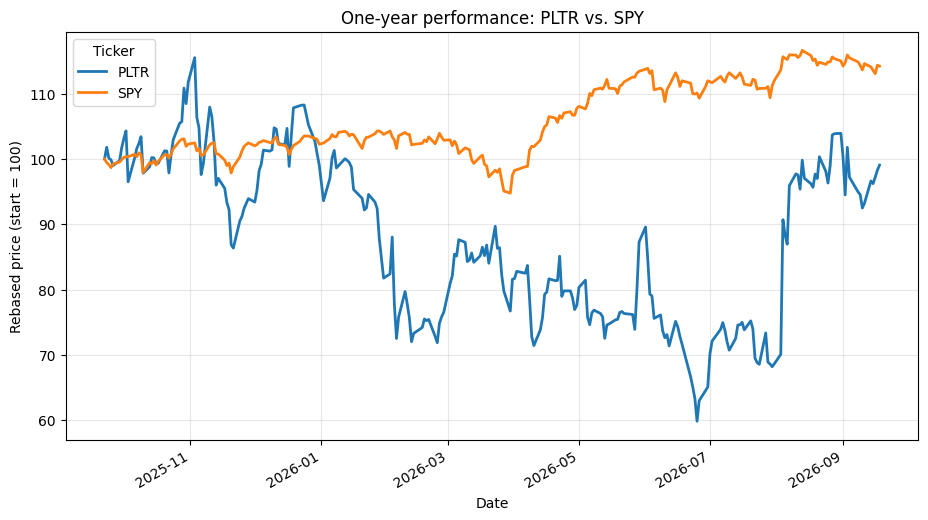

In [7]:
rebased = prices / prices.iloc[0] * 100

ax = rebased.plot(figsize=(11, 6), linewidth=2)
ax.set_title(f"One-year performance: {TICKER} vs. {BENCHMARK}")
ax.set_xlabel("Date")
ax.set_ylabel("Rebased price (start = 100)")
ax.legend(title="Ticker")
ax.grid(alpha=0.3)
plt.show()

## 4. Find the largest one-day move

`abs()` lets us find the biggest move whether it was up or down. The short write-up below explains the event and links to Palantir's earnings release.

In [8]:
ticker_returns = daily_returns[TICKER]
largest_move_date = ticker_returns.abs().idxmax()
largest_move = ticker_returns.loc[largest_move_date]

direction = "up" if largest_move > 0 else "down"
print(
    f"{TICKER}'s largest single-day move was {direction} "
    f"{abs(largest_move):.2%} on {largest_move_date.date()}."
)

PLTR's largest single-day move was up 29.45% on 2026-08-04.


## 5. Short write-up

**What happened on the biggest-move date:** On August 4, 2026, PLTR rose 29.45% after Palantir reported exceptionally strong second-quarter results, including 93% year-over-year revenue growth and 149% growth in U.S. commercial revenue. Investors also reacted to management's largest-ever guidance increase, which suggested that demand for the company's AI software was accelerating. These results are reported in [Palantir's Q2 2026 earnings release](https://www.sec.gov/Archives/edgar/data/1321655/000132165526000039/a2026q2ex991pressrelease.htm).

**What the chart shows:** Over the year ending September 18, 2026, PLTR returned -0.94%, while SPY returned 14.22%, so PLTR lagged the market. PLTR's annualised volatility was 60.78%, far above SPY's 12.95%, making it a much rougher ride. I would be cautious about holding PLTR because its growth story is compelling, but its much higher volatility and weaker one-year performance make it riskier than the broad market.